## Sample Data Development

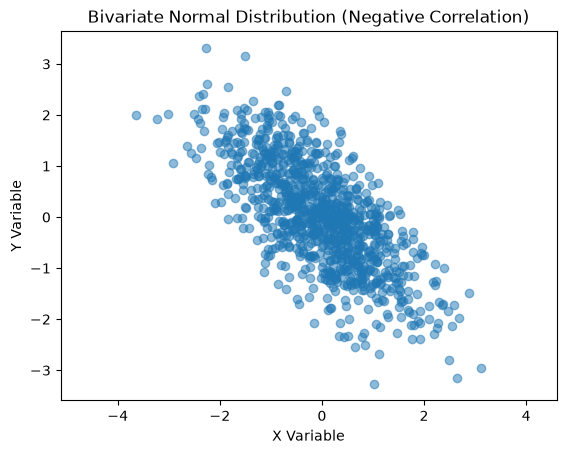

In [44]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

rng = np.random.default_rng(seed=123)

mean = [0, 0]
# Negative correlation (-0.7) between the variables
cov = [[1.0, -0.7], 
       [-0.7, 1.0]]

# Generate 1000 data points
data = rng.multivariate_normal(mean, cov, size=1000)

# Plotting
plt.scatter(data[:, 0], data[:, 1], alpha=0.5)
plt.title("Bivariate Normal Distribution (Negative Correlation)")
plt.xlabel("X Variable")
plt.ylabel("Y Variable")
plt.axis("equal")
plt.show()


In [45]:
### Two 2D Gaussian distributions with the same number of events
n_events = 2000

### Background is sampled from N(mu0, Sigma0)
mu0 = np.array([-1.0, -1.0])
cov0 = np.array([[1.0, 0.2],
                 [0.2, 1.2]])
x0 = np.random.multivariate_normal(mu0, cov0, size=n_events)
y0 = np.zeros((n_events, 1), dtype=np.float32)

### Signal is sampled from N(mu1, Sigma1)
mu1 = np.array([1.0, 1.0])
cov1 = np.array([[1.3, -0.3],
                 [-0.3, 0.8]])
x1 = np.random.multivariate_normal(mu1, cov1, size=n_events)
y1 = np.ones((n_events, 1), dtype=np.float32)

X = np.vstack([x0, x1]).astype(np.float32)
y = np.vstack([y0, y1]).astype(np.float32)

### Put these together and shuffle
idx = np.random.permutation(len(X))
X = X[idx] # inputs
y = y[idx] # labels

print("Data shapes:", X.shape, y.shape)

Data shapes: (4000, 2) (4000, 1)


In [46]:
df = pd.DataFrame(np.hstack([X,y]), columns = ["theta_1", "theta_2", "label"])
df

,theta_1,theta_2,label
0,0.689577,1.488070,1.0
1,0.653413,3.181029,1.0
2,2.387596,-1.046505,1.0
3,-1.877715,0.274193,0.0
4,-0.024480,-2.793412,0.0
...,...,...,...
3995,0.823316,1.443080,1.0
3996,-1.644202,-2.028211,0.0
3997,2.928519,0.672244,1.0
3998,0.401979,1.344824,1.0


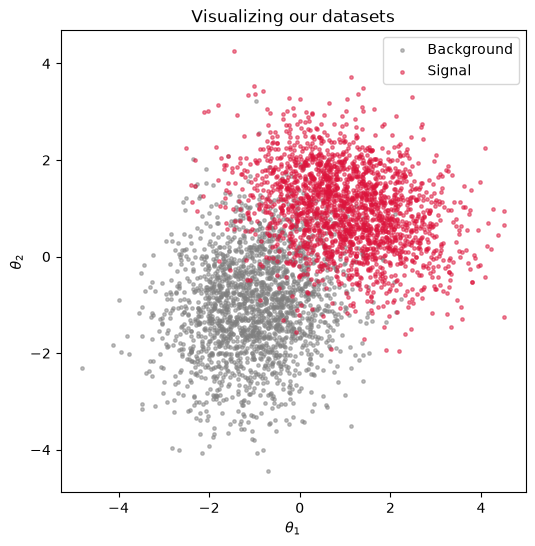

In [47]:
plt.figure(figsize=(6,6))
plt.scatter(df[df.label != True].theta_1, df[df.label != True].theta_2, s=6, color="grey", alpha=0.5, label="Background")
plt.scatter(df[df.label == True].theta_1, df[df.label == True].theta_2, s=6, color="crimson", alpha=0.5, label="Signal")
plt.legend()
plt.title("Visualizing our datasets")
plt.xlabel(r"$\theta_1$"); plt.ylabel(r"$\theta_2$")
plt.show()


In [48]:
## sample for cwola ?????

n_events = 2000

### Background: "flat" — uniform distribution (platykurtic, no peak)
### Use a uniform square/box rather than a Gaussian
x0 = np.random.uniform(low=-2.0, high=2.0, size=(n_events, 2))
y0 = np.zeros((n_events, 1), dtype=np.float32)

### Signal: "peaked" — e.g. Laplace distribution (leptokurtic, sharp peak + heavy tails)
x1 = np.random.laplace(loc=0.0, scale=0.8, size=(n_events, 2))
y1 = np.ones((n_events, 1), dtype=np.float32)

X = np.vstack([x0, x1]).astype(np.float32)
y = np.vstack([y0, y1]).astype(np.float32)

idx = np.random.permutation(len(X))
X = X[idx]
y = y[idx]

print("Data shapes:", X.shape, y.shape)

Data shapes: (4000, 2) (4000, 1)


In [49]:
df = pd.DataFrame(np.hstack([X,y]), columns = ["p1", "p2", "label"])
df

,p1,p2,label
0,-0.556883,-0.134774,0.0
1,-1.369465,0.194972,1.0
2,-0.661677,0.662372,1.0
3,-0.028605,-1.142036,1.0
4,-0.663659,-0.624282,1.0
...,...,...,...
3995,0.059031,-0.003384,1.0
3996,-1.333347,0.215126,1.0
3997,-0.278177,-0.636599,1.0
3998,1.309834,-1.213677,0.0


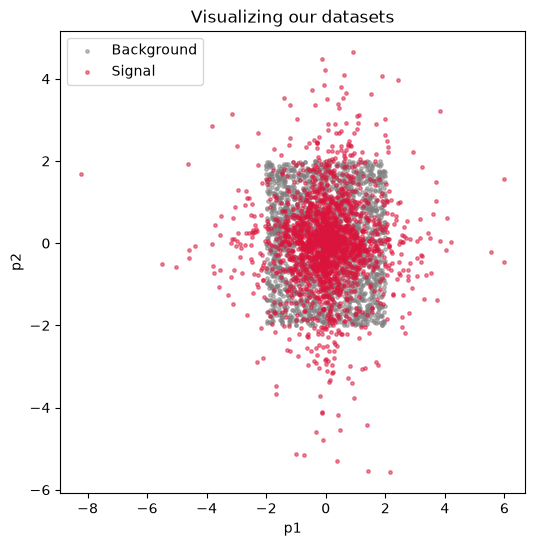

In [50]:
plt.figure(figsize=(6,6))
plt.scatter(df[df.label != True].p1, df[df.label != True].p2, s=6, color="grey", alpha=0.5, label="Background")
plt.scatter(df[df.label == True].p1, df[df.label == True].p2, s=6, color="crimson", alpha=0.5, label="Signal")
plt.legend()
plt.title("Visualizing our datasets")
plt.xlabel('p1'); plt.ylabel('p2')
plt.show()

In [51]:
## for point, part of background or signal?

In [1]:
# try again, visualize with 2 features

n_samples = 1000
n_features = 2

# flat background
Xb = np.random.uniform(low=0.0, high=10.0, size=(900, n_features))
yb = np.zeros(900) # Label 0 for background

# peaked stars
# We use a normal (Gaussian) distribution so the signal clusters tightly around a specific value (e.g., 5.0)
Xs = np.random.normal(loc=5.0, scale=1, size=(100, n_features))
ys = np.ones(100) # Label 1 for signal

# 3. Combine them into your final dataset
X = np.vstack((Xb, Xs))
y = np.concatenate((yb, ys))

print(f"Total X shape: {X.shape}") # Should be (1000, 5)
print(f"Total y shape: {y.shape}") # Should be (1000,)

df = pd.DataFrame(np.column_stack([X,y]), columns = ["p1", "p2", "label"])
print(df)

plt.figure(figsize=(6,6))
plt.scatter(df[df.label != True].p1, df[df.label != True].p2, s=6, color="grey", alpha=0.5, label="Background")
plt.scatter(df[df.label == True].p1, df[df.label == True].p2, s=6, color="crimson", alpha=0.5, label="Signal")
plt.legend()
plt.title("Visualizing our datasets")
plt.xlabel('p1'); plt.ylabel('p2')
plt.show()

NameError: name 'np' is not defined

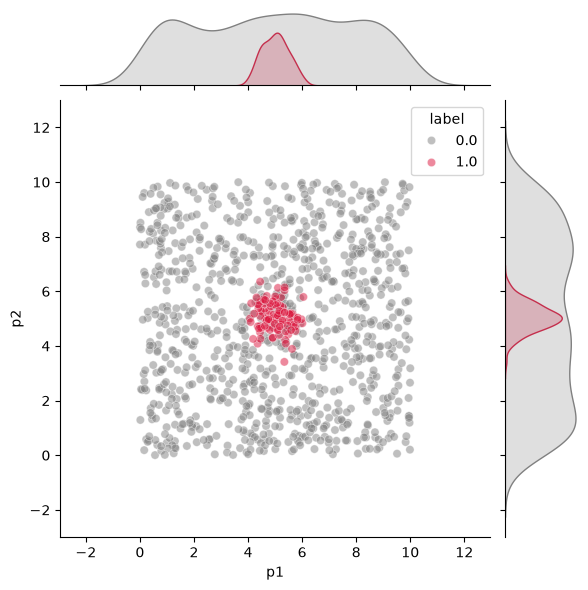

In [ ]:
import seaborn as sns

# This creates a scatter plot in the middle, but adds density curves (the peaks!) on the top and side axes
sns.jointplot(data=df, x="p1", y="p2", hue="label", palette={0: "grey", 1: "crimson"}, alpha=0.5)
plt.show()

## Data for model

In [54]:
# 5 features

n_samples = 1000
n_features = 5

X = []
y = []

# 1. Generate the "Mostly Flat" Background (900 stars)
# We use a uniform distribution to simulate a flat, random background across all 5 features
Xb = np.random.uniform(low=0.0, high=10.0, size=(900, n_features))
yb = np.zeros(900) # Label 0 for background

# 2. Generate the "Peaked" Signal (100 stars)
# We use a normal (Gaussian) distribution so the signal clusters tightly around a specific value (e.g., 5.0)
Xs = np.random.normal(loc=5.0, scale=0.5, size=(100, n_features))
ys = np.ones(100) # Label 1 for signal

# 3. Combine them into your final dataset
X = np.vstack((Xb, Xs))
y = np.concatenate((yb, ys))

print(f"Total X shape: {X.shape}") # Should be (1000, 5)
print(f"Total y shape: {y.shape}") # Should be (1000,)

Total X shape: (1000, 5)
Total y shape: (1000,)


In [55]:
from sklearn.model_selection import train_test_split

X_train, X_valtest, y_train, y_valtest = train_test_split(X, y, test_size=0.3)
X_val, X_test, y_val, y_test = train_test_split(X_valtest, y_valtest, test_size=0.5)


print(f"Training set has {len(X_train)} events.")
print(f"Validation set has {len(X_val)} events.")
print(f"Test set has {len(X_test)} events.")

Training set has 700 events.
Validation set has 150 events.
Test set has 150 events.


In [56]:
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

X_train_tensor = torch.tensor(X_train)
y_train_tensor = torch.tensor(y_train)

X_val_tensor = torch.tensor(X_val)
y_val_tensor = torch.tensor(y_val)

X_test_tensor = torch.tensor(X_test)
y_test_tensor = torch.tensor(y_test)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size = 32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

## Implement model

In [57]:
class NeuralNetwork(nn.Module):
    def __init__(self, input_dim = 5, hidden_dim1 = 256, hidden_dim2 = 256, hidden_dim3 = 256, output_dim = 1):
        super().__init__() # access all methods, attributes, etc of class
        self.NeuralNetwork = nn.Sequential(
            nn.Linear(input_dim, hidden_dim1),
            nn.ReLU(),                           ## add dropout layers?? HERE !!!! -------
            nn.Linear(hidden_dim1, hidden_dim2),
            nn.ReLU(),
            nn.Linear(hidden_dim2, hidden_dim3),
            nn.ReLU(),
            nn.Linear(hidden_dim3, output_dim),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.NeuralNetwork(x)

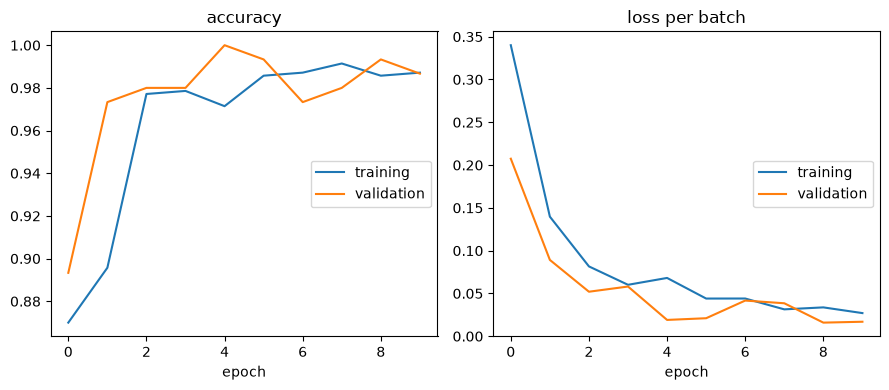

accuracy
	training         	 (min:    0.870, max:    0.991, cur:    0.987)
	validation       	 (min:    0.893, max:    1.000, cur:    0.987)
loss per batch
	training         	 (min:    0.027, max:    0.340, cur:    0.027)
	validation       	 (min:    0.016, max:    0.207, cur:    0.017)
Epoch 9, Loss: 0.0009886892512440681


In [58]:
# training loop and plots

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') # requires previous check for gpu
print(f'Using device: {device}')

model = NeuralNetwork(input_dim = 5, hidden_dim1 = 256, hidden_dim2 = 256, hidden_dim3 = 256, output_dim = 1).to(device)
loss_fn = nn.BCELoss() # common loss function for multi-class classification problems
optimizer = torch.optim.Adam(model.parameters(), lr=0.001) # default learning rate for Adam optimizer is 0.001

from livelossplot import PlotLosses
liveloss = PlotLosses(figsize=(9,4))

logs = {}

for epoch in range(10):  # loop over the dataset multiple times

    # training
    model.train()
    total_train_loss = 0
    train_acc, count = 0.0, 0
    for inputs, labels in train_loader:
        optimizer.zero_grad()  # zero the parameter gradients, updates weights only on the mini batch
        inputs, labels = inputs.to(device).float(), labels.to(device).float()
        out = model(inputs)  # forward pass
        loss = loss_fn(out.squeeze(), labels)  # compute loss

        loss.backward()  # backward pass
    
        optimizer.step()  # update parameters
        total_train_loss += loss.item()

        predicted = (out.squeeze() >= 0.5).float()
        train_acc += (predicted == labels).sum().item()
        count += labels.size(0)


    train_loss_per_batch = total_train_loss / len(train_loader)
    logs['loss per batch'] = train_loss_per_batch

    train_acc_per_count = train_acc/count
    logs['accuracy'] = train_acc_per_count


    # validation
    model.eval()
    all_predictions = []
    all_labels = []
    total_val_loss = 0
    val_acc, count = 0.0, 0
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device).float(), labels.to(device).float()

        out = model(inputs)  # forward pass
        loss = loss_fn(out.squeeze(), labels)  # compute loss
        total_val_loss += loss.item()

        predicted = (out.squeeze() >= 0.5).float()        
        val_acc += (predicted == labels).sum().item()
        count += labels.size(0)

        all_predictions.extend(predicted.numpy())
        all_labels.extend(labels.cpu().numpy())

    val_loss_per_batch = total_val_loss / len(val_loader)
    logs['val_loss per batch'] = val_loss_per_batch

    val_acc_per_count = val_acc/count
    logs['val_accuracy'] = val_acc_per_count

    liveloss.update(logs)
    liveloss.send()
    print(f'Epoch {epoch}, Loss: {loss.item()}')


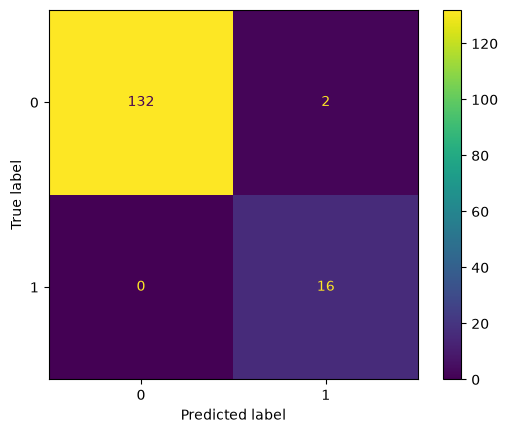

In [59]:
# confusion matrix, compares predicted labels with actual labels
# columns = predicted classes, rows = actual classes

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(all_labels, all_predictions)
cm_display = ConfusionMatrixDisplay(confusion_matrix = cm)
cm_display.plot()
plt.show()

In [60]:
model.eval()
test_loss, test_acc, count = 0.0, 0.0, 0
all_predictions = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        
        inputs = inputs.to(device).float()
        labels = labels.to(device).float()
    
        out = model(inputs)
        loss = loss_fn(out.squeeze(), labels)
        test_loss += loss.item() * inputs.size(0)

        predicted = (out.squeeze() >= 0.5).float()
            
        # Track counts
        test_acc += (predicted == labels).sum().item()
        count += labels.size(0)

print(f"Average test loss: {test_loss/count:.4f} | Test accuracy: {test_acc/count:.3f}")

Average test loss: 0.0486 | Test accuracy: 0.980


## Standardized data

In [64]:
from sklearn.preprocessing import StandardScaler

### initialize the scaler
scaler = StandardScaler()

### IMPORTANT -- you only want to define your scaling ("fit_transform") based on your training dataset.
X_train_scaled = scaler.fit_transform(X_train)

### Now re-use the same transformation on validation & test sets ("transform")
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print("Train mean (before scaling):", np.array(X_train.mean(axis=0)))
print("Train mean (after scaling) -- each dimension should be close to 0:", X_train_scaled.mean(axis=0))
print("Train std (before scaling)", np.array(X_train.std(axis=0)))
print("Train std (after scaling) -- each dimension should be close to 1:", X_train_scaled.std(axis=0))

Train mean (before scaling): [5.01135501 5.02373707 5.05260086 5.08285583 4.96440509]
Train mean (after scaling) -- each dimension should be close to 0: [-2.52750202e-15 -1.22933409e-15  2.52496436e-16 -7.92461335e-16
  3.06421555e-16]
Train std (before scaling) [2.7097656  2.70528192 2.79645288 2.69879996 2.73305566]
Train std (after scaling) -- each dimension should be close to 1: [1. 1. 1. 1. 1.]


In [65]:
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

X_train_scaled_tensor = torch.tensor(X_train_scaled)
y_train_tensor = torch.tensor(y_train)

X_val_scaled_tensor = torch.tensor(X_val_scaled)
y_val_tensor = torch.tensor(y_val)

X_test_scaled_tensor = torch.tensor(X_test_scaled)
y_test_tensor = torch.tensor(y_test)

train_dataset = TensorDataset(X_train_scaled_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_scaled_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_scaled_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size = 32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

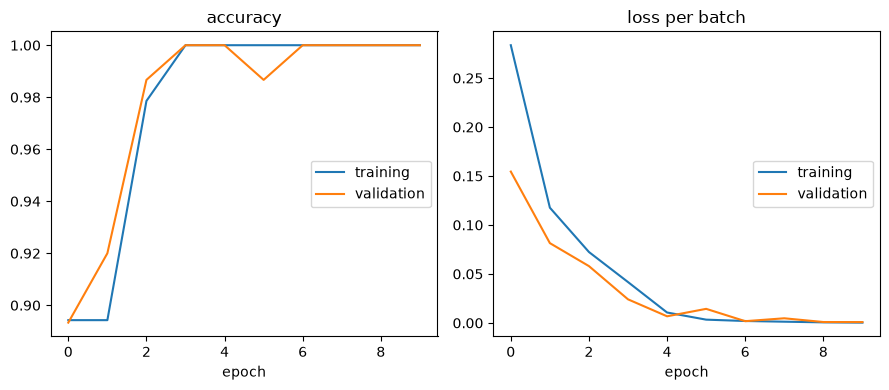

accuracy
	training         	 (min:    0.894, max:    1.000, cur:    1.000)
	validation       	 (min:    0.893, max:    1.000, cur:    1.000)
loss per batch
	training         	 (min:    0.000, max:    0.284, cur:    0.000)
	validation       	 (min:    0.001, max:    0.154, cur:    0.001)
Epoch 9, Loss: 7.805423956597224e-05
[array([2.22841e-23], dtype=float32), array([2.4536068e-17], dtype=float32), array([1.3262389e-18], dtype=float32), array([2.7400844e-21], dtype=float32), array([1.9557044e-21], dtype=float32), array([5.9890575e-19], dtype=float32), array([1.3141035e-16], dtype=float32), array([6.169195e-08], dtype=float32), array([0.9984925], dtype=float32), array([1.9993478e-16], dtype=float32), array([5.6760807e-12], dtype=float32), array([1.3120555e-15], dtype=float32), array([2.5964122e-18], dtype=float32), array([7.381512e-21], dtype=float32), array([1.8136442e-20], dtype=float32), array([1.8605667e-13], dtype=float32), array([1.2534318e-19], dtype=float32), array([1.9947126e-0

In [81]:
# training loop and plots

class NeuralNetwork(nn.Module):
    def __init__(self, input_dim = 5, hidden_dim1 = 256, hidden_dim2 = 256, hidden_dim3 = 256, output_dim = 1):
        super().__init__() # access all methods, attributes, etc of class
        self.NeuralNetwork = nn.Sequential(
            nn.Linear(input_dim, hidden_dim1),
            nn.ReLU(),                           ## add dropout layers?? HERE !!!! -------
            nn.Linear(hidden_dim1, hidden_dim2),
            nn.ReLU(),
            nn.Linear(hidden_dim2, hidden_dim3),
            nn.ReLU(),
            nn.Linear(hidden_dim3, output_dim),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.NeuralNetwork(x)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') # requires previous check for gpu
print(f'Using device: {device}')

model = NeuralNetwork(input_dim = 5, hidden_dim1 = 256, hidden_dim2 = 256, hidden_dim3 = 256, output_dim = 1).to(device)
loss_fn = nn.BCELoss() # common loss function for multi-class classification problems
optimizer = torch.optim.Adam(model.parameters(), lr=0.001) # default learning rate for Adam optimizer is 0.001

from livelossplot import PlotLosses
liveloss = PlotLosses(figsize=(9,4))

logs = {}

for epoch in range(10):  # loop over the dataset multiple times

    # training
    model.train()
    total_train_loss = 0
    train_acc, count = 0.0, 0
    for inputs, labels in train_loader:
        optimizer.zero_grad()  # zero the parameter gradients, updates weights only on the mini batch
        inputs, labels = inputs.to(device).float(), labels.to(device).float()
        out = model(inputs)  # forward pass
        loss = loss_fn(out.squeeze(), labels)  # compute loss

        loss.backward()  # backward pass
    
        optimizer.step()  # update parameters
        total_train_loss += loss.item()

        predicted = (out.squeeze() >= 0.5).float()
        train_acc += (predicted == labels).sum().item()
        count += labels.size(0)


    train_loss_per_batch = total_train_loss / len(train_loader)
    logs['loss per batch'] = train_loss_per_batch

    train_acc_per_count = train_acc/count
    logs['accuracy'] = train_acc_per_count


    # validation
    model.eval()
    out_values = []
    all_predictions = []
    all_labels = []
    total_val_loss = 0
    val_acc, count = 0.0, 0
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device).float(), labels.to(device).float()

        out = model(inputs)  # forward pass
        out_values.extend(out.detach().numpy())
        loss = loss_fn(out.squeeze(), labels)  # compute loss
        total_val_loss += loss.item()

        predicted = (out.squeeze() >= 0.5).float()        
        val_acc += (predicted == labels).sum().item()
        count += labels.size(0)

        all_predictions.extend(predicted.numpy())
        all_labels.extend(labels.cpu().numpy())

    val_loss_per_batch = total_val_loss / len(val_loader)
    logs['val_loss per batch'] = val_loss_per_batch

    val_acc_per_count = val_acc/count
    logs['val_accuracy'] = val_acc_per_count

    liveloss.update(logs)
    liveloss.send()
    print(f'Epoch {epoch}, Loss: {loss.item()}')

    print(out_values)


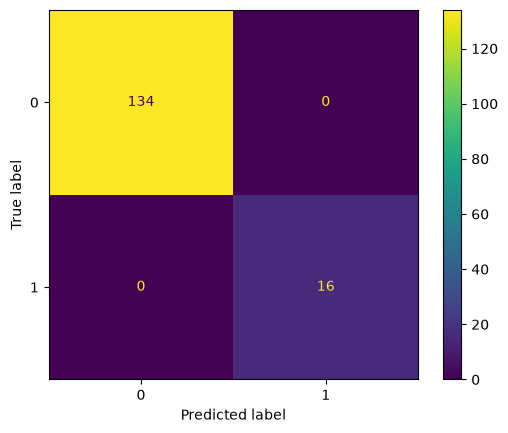

In [71]:
# confusion matrix, compares predicted labels with actual labels
# columns = predicted classes, rows = actual classes

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(all_labels, all_predictions)
cm_display = ConfusionMatrixDisplay(confusion_matrix = cm)
cm_display.plot()
plt.show()

In [72]:
model.eval()
test_loss, test_acc, count = 0.0, 0.0, 0
all_predictions = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        
        inputs = inputs.to(device).float()
        labels = labels.to(device).float()
    
        out = model(inputs)
        loss = loss_fn(out.squeeze(), labels)
        test_loss += loss.item() * inputs.size(0)

        predicted = (out.squeeze() >= 0.5).float()
            
        # Track counts
        test_acc += (predicted == labels).sum().item()
        count += labels.size(0)

print(f"Average test loss: {test_loss/count:.4f} | Test accuracy: {test_acc/count:.3f}")

Average test loss: 0.0454 | Test accuracy: 0.993


## try BCE with Logits loss function

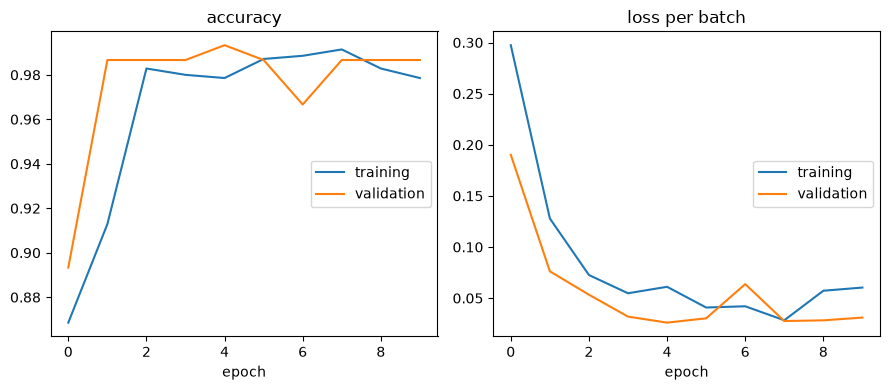

accuracy
	training         	 (min:    0.869, max:    0.991, cur:    0.979)
	validation       	 (min:    0.893, max:    0.993, cur:    0.987)
loss per batch
	training         	 (min:    0.028, max:    0.297, cur:    0.060)
	validation       	 (min:    0.026, max:    0.190, cur:    0.031)
Epoch 9, Loss: 0.009986784309148788


In [61]:
## BCE LOGITS

class NeuralNetwork(nn.Module):
    def __init__(self, input_dim = 5, hidden_dim1 = 256, hidden_dim2 = 256, hidden_dim3 = 256, output_dim = 1):
        super().__init__() # access all methods, attributes, etc of class
        self.NeuralNetwork = nn.Sequential(
            nn.Linear(input_dim, hidden_dim1),
            nn.ReLU(),                           ## add dropout layers?? HERE !!!! -------
            nn.Linear(hidden_dim1, hidden_dim2),
            nn.ReLU(),
            nn.Linear(hidden_dim2, hidden_dim3),
            nn.ReLU(),
            nn.Linear(hidden_dim3, output_dim)
                            )
    def forward(self, x):
        return self.NeuralNetwork(x)

# training loop and plots

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') # requires previous check for gpu
print(f'Using device: {device}')

model = NeuralNetwork(input_dim = 5, hidden_dim1 = 256, hidden_dim2 = 256, hidden_dim3 = 256, output_dim = 1).to(device)
loss_fn = nn.BCEWithLogitsLoss() # common loss function for multi-class classification problems
optimizer = torch.optim.Adam(model.parameters(), lr=0.001) # default learning rate for Adam optimizer is 0.001

from livelossplot import PlotLosses
liveloss = PlotLosses(figsize=(9,4))

logs = {}

for epoch in range(10):  # loop over the dataset multiple times

    # training
    model.train()
    total_train_loss = 0
    train_acc, count = 0.0, 0
    for inputs, labels in train_loader:
        optimizer.zero_grad()  # zero the parameter gradients, updates weights only on the mini batch
        inputs, labels = inputs.to(device).float(), labels.to(device).float()

        out = model(inputs)  # forward pass
        loss = loss_fn(out.squeeze(), labels)  # compute loss

        loss.backward()  # backward pass
    
        optimizer.step()  # update parameters
        total_train_loss += loss.item()

        predicted = (out.squeeze() >= 0.0).float()
        train_acc += (predicted == labels).sum().item()
        count += labels.size(0)


    train_loss_per_batch = total_train_loss / len(train_loader)
    logs['loss per batch'] = train_loss_per_batch

    train_acc_per_count = train_acc/count
    logs['accuracy'] = train_acc_per_count


    # validation
    model.eval()
    all_predictions = []
    all_labels = []
    total_val_loss = 0
    val_acc, count = 0.0, 0
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device).float(), labels.to(device).float()

        out = model(inputs)  # forward pass
        loss = loss_fn(out.squeeze(), labels)  # compute loss
        total_val_loss += loss.item()

        predicted = (out.squeeze() >= 0.0).float()        
        val_acc += (predicted == labels).sum().item()
        count += labels.size(0)

        all_predictions.extend(predicted.numpy())
        all_labels.extend(labels.cpu().numpy())

    val_loss_per_batch = total_val_loss / len(val_loader)
    logs['val_loss per batch'] = val_loss_per_batch

    val_acc_per_count = val_acc/count
    logs['val_accuracy'] = val_acc_per_count

    liveloss.update(logs)
    liveloss.send()
    print(f'Epoch {epoch}, Loss: {loss.item()}')

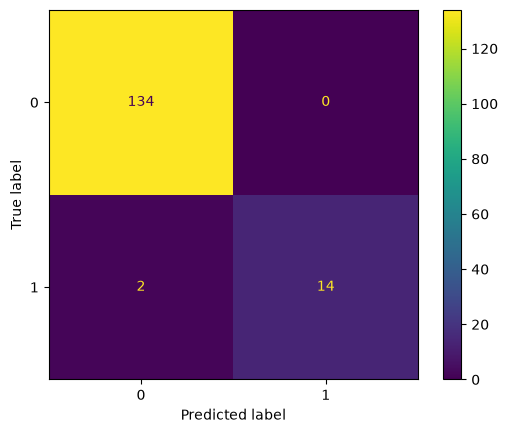

In [62]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(all_labels, all_predictions)
cm_display = ConfusionMatrixDisplay(confusion_matrix = cm)
cm_display.plot()
plt.show()

In [63]:
model.eval()
test_loss, test_acc, count = 0.0, 0.0, 0
all_predictions = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        
        inputs = inputs.to(device).float()
        labels = labels.to(device).float()
    
        out = model(inputs)
        loss = loss_fn(out.squeeze(), labels)
        test_loss += loss.item() * inputs.size(0)

        predicted = (out.squeeze() >= 0.0).float()
            
        # Track counts
        test_acc += (predicted == labels).sum().item()
        count += labels.size(0)

print(f"Average test loss: {test_loss/count:.4f} | Test accuracy: {test_acc/count:.3f}")

Average test loss: 0.0461 | Test accuracy: 0.980


## Weakly supervised test

In [92]:

n_features = 5

X = []
y = []

Xb = np.random.uniform(low=0.0, high=10.0, size=(900, n_features))
Xs = np.random.normal(loc=5.0, scale=0.5, size=(100, n_features))

Xb_sigregion = Xb[:450] 
Xb_backregion = Xb[450:]

# signal region
X_sigregion = np.vstack((Xb_sigregion, Xs))
y_sigregion = np.ones(len(X_sigregion)) 

# pure background region
X_backregion = Xb_backregion
y_backregion = np.zeros(len(X_backregion))

X_weak = np.vstack((X_sigregion, X_backregion))
y_weak = np.concatenate((y_sigregion, y_backregion))


from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X_weak, y_weak, test_size=0.2)



# Generate fresh testing data
X_test_bg = np.random.uniform(low=0.0, high=10.0, size=(90, n_features))
y_test_bg = np.zeros(90) # TRUE label: 0

X_test_sig = np.random.normal(loc=5.0, scale=0.5, size=(10, n_features))
y_test_sig = np.ones(10) # TRUE label: 1

# Combine them
X_test = np.vstack((X_test_bg, X_test_sig))
y_test = np.concatenate((y_test_bg, y_test_sig))


print(f"Training set has {len(X_train)} events.")
print(f"Validation set has {len(X_val)} events.")
print(f"Test set has {len(X_test)} events.")

Training set has 800 events.
Validation set has 200 events.
Test set has 100 events.


In [93]:
from sklearn.preprocessing import StandardScaler

### initialize the scaler
scaler = StandardScaler()

### IMPORTANT -- you only want to define your scaling ("fit_transform") based on your training dataset.
X_train_scaled = scaler.fit_transform(X_train)

### Now re-use the same transformation on validation & test sets ("transform")
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print("Train mean (before scaling):", np.array(X_train.mean(axis=0)))
print("Train mean (after scaling) -- each dimension should be close to 0:", X_train_scaled.mean(axis=0))
print("Train std (before scaling)", np.array(X_train.std(axis=0)))
print("Train std (after scaling) -- each dimension should be close to 1:", X_train_scaled.std(axis=0))

Train mean (before scaling): [4.99697059 4.86010274 4.90806509 5.07447706 5.05676328]
Train mean (after scaling) -- each dimension should be close to 0: [-1.38777878e-18  2.32321107e-15  1.65450986e-15  1.51462176e-15
 -7.97278910e-16]
Train std (before scaling) [2.83579556 2.71647537 2.7612208  2.725512   2.72801912]
Train std (after scaling) -- each dimension should be close to 1: [1. 1. 1. 1. 1.]


In [94]:
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

X_train_scaled_tensor = torch.tensor(X_train_scaled)
y_train_tensor = torch.tensor(y_train)

X_val_scaled_tensor = torch.tensor(X_val_scaled)
y_val_tensor = torch.tensor(y_val)

X_test_scaled_tensor = torch.tensor(X_test_scaled)
y_test_tensor = torch.tensor(y_test)

train_dataset = TensorDataset(X_train_scaled_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_scaled_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_scaled_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size = 32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

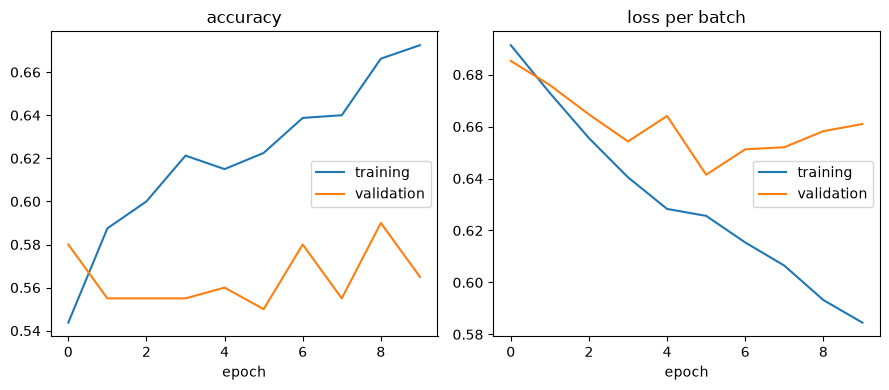

accuracy
	training         	 (min:    0.544, max:    0.672, cur:    0.672)
	validation       	 (min:    0.550, max:    0.590, cur:    0.565)
loss per batch
	training         	 (min:    0.585, max:    0.691, cur:    0.585)
	validation       	 (min:    0.641, max:    0.685, cur:    0.661)
Epoch 9, Loss: 0.7118342518806458


In [95]:
# training loop and plots

class NeuralNetwork(nn.Module):
    def __init__(self, input_dim = 5, hidden_dim1 = 256, hidden_dim2 = 256, hidden_dim3 = 256, output_dim = 1):
        super().__init__() # access all methods, attributes, etc of class
        self.NeuralNetwork = nn.Sequential(
            nn.Linear(input_dim, hidden_dim1),
            nn.ReLU(),                           ## add dropout layers?? HERE !!!! -------
            nn.Linear(hidden_dim1, hidden_dim2),
            nn.ReLU(),
            nn.Linear(hidden_dim2, hidden_dim3),
            nn.ReLU(),
            nn.Linear(hidden_dim3, output_dim),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.NeuralNetwork(x)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') # requires previous check for gpu
print(f'Using device: {device}')

model = NeuralNetwork(input_dim = 5, hidden_dim1 = 256, hidden_dim2 = 256, hidden_dim3 = 256, output_dim = 1).to(device)
loss_fn = nn.BCELoss() # common loss function for multi-class classification problems
optimizer = torch.optim.Adam(model.parameters(), lr=0.001) # default learning rate for Adam optimizer is 0.001

from livelossplot import PlotLosses
liveloss = PlotLosses(figsize=(9,4))

logs = {}

for epoch in range(10):  # loop over the dataset multiple times

    # training
    model.train()
    total_train_loss = 0
    train_acc, count = 0.0, 0
    for inputs, labels in train_loader:
        optimizer.zero_grad()  # zero the parameter gradients, updates weights only on the mini batch
        inputs, labels = inputs.to(device).float(), labels.to(device).float()
        out = model(inputs)  # forward pass
        loss = loss_fn(out.squeeze(), labels)  # compute loss

        loss.backward()  # backward pass
    
        optimizer.step()  # update parameters
        total_train_loss += loss.item()

        predicted = (out.squeeze() >= 0.5).float()
        train_acc += (predicted == labels).sum().item()
        count += labels.size(0)


    train_loss_per_batch = total_train_loss / len(train_loader)
    logs['loss per batch'] = train_loss_per_batch

    train_acc_per_count = train_acc/count
    logs['accuracy'] = train_acc_per_count


    # validation
    model.eval()
    out_values = []
    all_predictions = []
    all_labels = []
    total_val_loss = 0
    val_acc, count = 0.0, 0
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device).float(), labels.to(device).float()

        out = model(inputs)  # forward pass
        out_values.extend(out.detach().numpy())
        loss = loss_fn(out.squeeze(), labels)  # compute loss
        total_val_loss += loss.item()

        predicted = (out.squeeze() >= 0.5).float()        
        val_acc += (predicted == labels).sum().item()
        count += labels.size(0)

        all_predictions.extend(predicted.numpy())
        all_labels.extend(labels.cpu().numpy())

    val_loss_per_batch = total_val_loss / len(val_loader)
    logs['val_loss per batch'] = val_loss_per_batch

    val_acc_per_count = val_acc/count
    logs['val_accuracy'] = val_acc_per_count

    liveloss.update(logs)
    liveloss.send()
    print(f'Epoch {epoch}, Loss: {loss.item()}')

In [96]:
model.eval()
test_loss, test_acc, count = 0.0, 0.0, 0
all_predictions = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        
        inputs = inputs.to(device).float()
        labels = labels.to(device).float()
    
        out = model(inputs)
        loss = loss_fn(out.squeeze(), labels)
        test_loss += loss.item() * inputs.size(0)

        predicted = (out.squeeze() >= 0.0).float()
            
        # Track counts
        test_acc += (predicted == labels).sum().item()
        count += labels.size(0)

print(f"Average test loss: {test_loss/count:.4f} | Test accuracy: {test_acc/count:.3f}")

Average test loss: 0.6432 | Test accuracy: 0.100
